In [1]:
print("Zepto Analytics Project Started")

Zepto Analytics Project Started


# Zepto E-Commerce Data Analysis

## Project Overview

This project analyzes Zepto e-commerce product data to understand product distribution, pricing, discounts, product availability, inventory, weight, and quantity patterns.

The project uses Python for data cleaning, exploratory data analysis, visualization, and business insights.

## 2. Import Libraries

The following Python libraries are used for data manipulation, numerical analysis, and data visualization.

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
print("All libraries imported successfully")

All libraries imported successfully


## 3. Load Dataset

The Zepto product dataset is loaded into a Pandas DataFrame for further inspection, cleaning, and analysis.

In [6]:
# Load the Zepto dataset

df = pd.read_csv("zepto_v2(in).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
# check the number of rows and columns in the dataset
print("Number of rows :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows : 3732
Number of columns : 9


In [8]:
#display the first five rows

df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


In [9]:
#display column names
print("column names:")
print(df.columns.tolist())

column names:
['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity', 'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity']


In [10]:
#check datatypes and null vales in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Category                3732 non-null   str  
 1   name                    3732 non-null   str  
 2   mrp                     3732 non-null   int64
 3   discountPercent         3732 non-null   int64
 4   availableQuantity       3732 non-null   int64
 5   discountedSellingPrice  3732 non-null   int64
 6   weightInGms             3732 non-null   int64
 7   outOfStock              3732 non-null   bool 
 8   quantity                3732 non-null   int64
dtypes: bool(1), int64(6), str(2)
memory usage: 414.1 KB


## 4. Initial Data Inspection

Before performing data cleaning, the dataset is inspected to understand its structure, data types, missing values, duplicate records, and unique values.

In [11]:
#summary ststistics for numerical columns
df.describe()

,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,quantity
count,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000
mean,15680.117899,7.617095,4.008574,14192.834941,387.843783,213.270900
std,16088.807618,9.211733,2.203511,13850.726265,678.096509,194.730976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6000.000000,0.000000,2.000000,5500.000000,100.000000,50.000000
50%,11000.000000,6.000000,5.000000,10400.000000,225.000000,186.000000
75%,20000.000000,10.000000,6.000000,18400.000000,450.000000,340.000000
max,260000.000000,51.000000,6.000000,139900.000000,10000.000000,1500.000000


In [12]:
#check missing values in each columns
missing_values =df.isnull().sum()
print("missing values in each column:")
print(missing_values)

missing values in each column:
Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64


In [13]:
#check for the duplicate rows in the dataset
duplicate_values = df.duplicated().sum()
print("number of duplicate rows in the dataset:")
print(duplicate_values)

number of duplicate rows in the dataset:
2


In [14]:
#number of unique values in each column
unique_values = df.nunique()
print("number of unique values in each column:")
print(unique_values)

number of unique values in each column:
Category                    14
name                      1681
mrp                        266
discountPercent             42
availableQuantity            7
discountedSellingPrice     350
weightInGms                158
outOfStock                   2
quantity                   143
dtype: int64


In [15]:
# Unique product categories

print("Number of categories:", df["Category"].nunique())

print("\nCategories:")
print(df["Category"].unique())

Number of categories: 14

Categories:
<ArrowStringArray>
[  'Fruits & Vegetables',    'Cooking Essentials',              'Munchies',
 'Dairy, Bread & Batter',             'Beverages',         'Packaged Food',
  'Ice Cream & Desserts',  'Chocolates & Candies',    'Meats, Fish & Eggs',
              'Biscuits',         'Personal Care',           'Paan Corner',
       'Home & Cleaning',      'Health & Hygiene']
Length: 14, dtype: str


In [16]:
# Number of unique products

print("Total product records:", len(df))
print("Unique product names:", df["name"].nunique())

Total product records: 3732
Unique product names: 1681


In [21]:
# Display data types

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

data_types

,Column,Data Type
0,Category,str
1,name,str
2,mrp,int64
3,discountPercent,int64
4,availableQuantity,int64
5,discountedSellingPrice,int64
6,weightInGms,int64
7,outOfStock,bool
8,quantity,int64


## 5. Data Cleaning & Validation

The dataset is cleaned and validated to ensure consistency, accuracy, and reliability before performing further analysis.

In [22]:
df_clean = df.copy()
print("copy created successfully")

copy created successfully


In [23]:
# check missing values in the working dataset

missing_values = df_clean.isnull().sum()
missing_values


Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64

In [24]:
# count duplicate rows in the working dataset

duplicate_values = df_clean.duplicated().sum()
print("duplicate rows :", duplicate_values)

duplicate rows : 2


In [25]:
# Check for negative values in numerical columns

numeric_columns = df_clean.select_dtypes(include=np.number).columns

negative_values = (df_clean[numeric_columns] < 0).sum()

negative_values

mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
quantity                  0
dtype: int64

In [29]:
#check products where seeling price is greater than mrp

invalid_prices = df_clean[df_clean["discountedSellingPrice"] > df_clean["mrp"]]
print("number of products with selling price greater than mrp :" , len(invalid_prices))

number of products with selling price greater than mrp : 0


In [32]:
# Check discount percentage range

print("Minimum discount:", df_clean["discountPercent"].min())
print("Maximum discount:", df_clean["discountPercent"].max())

Minimum discount: 0
Maximum discount: 51


In [33]:
# Check for discounts outside the expected 0–100% range

invalid_discount = df_clean[
    (df_clean["discountPercent"] < 0) |
    (df_clean["discountPercent"] > 100)
]

print("Invalid discount records:", len(invalid_discount))

Invalid discount records: 0


In [34]:
#display duplicate records
duplicates = df_clean[df_clean.duplicated(keep=False)]
duplicates

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
2908,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
2946,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3252,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3290,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250


In [35]:
print("total duplicate records:",len(duplicates))

total duplicate records: 4


In [36]:
# delete duplicate records 
before_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
after_duplicates = len(df_clean)
print("rows before removing duplicates:",before_duplicates)
print("rows after removing duplicates:",after_duplicates)
print("duplicates removed:" , before_duplicates - after_duplicates)

rows before removing duplicates: 3732
rows after removing duplicates: 3730
duplicates removed: 2


In [37]:
# verifying no duplicates remian in the dataset
print("duplicate rows:" , df_clean.duplicated().sum())

duplicate rows: 0


In [39]:
# converting price value from paise to rupee for better readibility
df_clean["mrp_rupees"] = df_clean["mrp"]/100
df_clean["selling_price_rupees"] = df_clean["discountedSellingPrice"]/100

df_clean[[
    "mrp",
    "mrp_rupees",
    "discountedSellingPrice",
    "selling_price_rupees"
]].head()

,mrp,mrp_rupees,discountedSellingPrice,selling_price_rupees
0,2500,25.0,2100,21.0
1,4200,42.0,3500,35.0
2,5100,51.0,4300,43.0
3,2000,20.0,1700,17.0
4,1400,14.0,1200,12.0


## 6. Feature Engineering

New analytical features are created from the existing product, pricing, discount, inventory, and weight information to support deeper business analysis.


In [40]:
# Calculate absolute savings for each product

df_clean["savings"] = (
    df_clean["mrp_rupees"] - df_clean["selling_price_rupees"]
)

df_clean[[
    "name",
    "mrp_rupees",
    "selling_price_rupees",
    "savings"
]].head()

,name,mrp_rupees,selling_price_rupees,savings
0,Onion,25.0,21.0,4.0
1,Tomato Hybrid,42.0,35.0,7.0
2,Tender Coconut,51.0,43.0,8.0
3,Coriander Leaves,20.0,17.0,3.0
4,Ladies Finger,14.0,12.0,2.0


In [41]:
# Create discount categories

df_clean["discount_category"] = pd.cut(
    df_clean["discountPercent"],
    bins=[-1, 0, 10, 25, 40, 100],
    labels=[
        "No Discount",
        "Low Discount",
        "Medium Discount",
        "High Discount",
        "Very High Discount"
    ]
)

df_clean["discount_category"].value_counts()

discount_category
Low Discount          1740
No Discount           1178
Medium Discount        634
High Discount          109
Very High Discount      69
Name: count, dtype: int64

In [42]:
# Create stock status

df_clean["stock_status"] = np.select(
    [
        df_clean["outOfStock"] == True,
        df_clean["availableQuantity"] <= 5,
        df_clean["availableQuantity"] > 5
    ],
    [
        "Out of Stock",
        "Low Stock",
        "In Stock"
    ],
    default="Unknown"
)

df_clean["stock_status"].value_counts()

stock_status
Low Stock       1659
In Stock        1618
Out of Stock     453
Name: count, dtype: int64

In [43]:
# Create selling price categories

df_clean["price_category"] = pd.cut(
    df_clean["selling_price_rupees"],
    bins=[-1, 50, 200, 500, 1000, np.inf],
    labels=[
        "Budget",
        "Affordable",
        "Mid-Range",
        "Premium",
        "High-End"
    ]
)

df_clean["price_category"].value_counts()

price_category
Affordable    2138
Budget         821
Mid-Range      659
Premium         98
High-End        14
Name: count, dtype: int64

In [44]:
# Create weight categories

df_clean["weight_category"] = pd.cut(
    df_clean["weightInGms"],
    bins=[-1, 250, 500, 1000, 2000, np.inf],
    labels=[
        "Light",
        "Medium",
        "Heavy",
        "Extra Heavy",
        "Bulk"
    ]
)

df_clean["weight_category"].value_counts()

weight_category
Light          2113
Medium         1107
Heavy           384
Extra Heavy      65
Bulk             61
Name: count, dtype: int64

In [45]:
# Create quantity categories

df_clean["quantity_category"] = pd.cut(
    df_clean["quantity"],
    bins=[-1, 1, 3, 5, 10, np.inf],
    labels=[
        "Single",
        "Small Pack",
        "Medium Pack",
        "Large Pack",
        "Bulk Pack"
    ]
)

df_clean["quantity_category"].value_counts()

quantity_category
Bulk Pack      3208
Single          291
Large Pack       95
Medium Pack      82
Small Pack       54
Name: count, dtype: int64

In [46]:
# Create a unique SKU ID

df_clean["sku_id"] = range(1, len(df_clean) + 1)

df_clean[[
    "sku_id",
    "Category",
    "name"
]].head()

,sku_id,Category,name
0,1,Fruits & Vegetables,Onion
1,2,Fruits & Vegetables,Tomato Hybrid
2,3,Fruits & Vegetables,Tender Coconut
3,4,Fruits & Vegetables,Coriander Leaves
4,5,Fruits & Vegetables,Ladies Finger


In [47]:
# Check all columns after feature engineering

print("Total columns:", len(df_clean.columns))
print("\nColumns:")
print(df_clean.columns.tolist())

Total columns: 18

Columns:
['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity', 'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity', 'mrp_rupees', 'selling_price_rupees', 'savings', 'discount_category', 'stock_status', 'price_category', 'weight_category', 'quantity_category', 'sku_id']


## 7. Exploratory Data Analysis

Exploratory Data Analysis is performed to identify patterns and relationships in product categories, pricing, discounts, availability, weight, and quantity.

### 7.1 Category Analysis

Category-level analysis is performed to understand the distribution of products across different product categories.

In [48]:
# Count the number of products in each category
category_product_count = (
    df_clean["Category"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Number of products by category:")
print(category_product_count)

Number of products by category:
Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            343
Paan Corner              343
Home & Cleaning          194
Biscuits                 147
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          97
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64


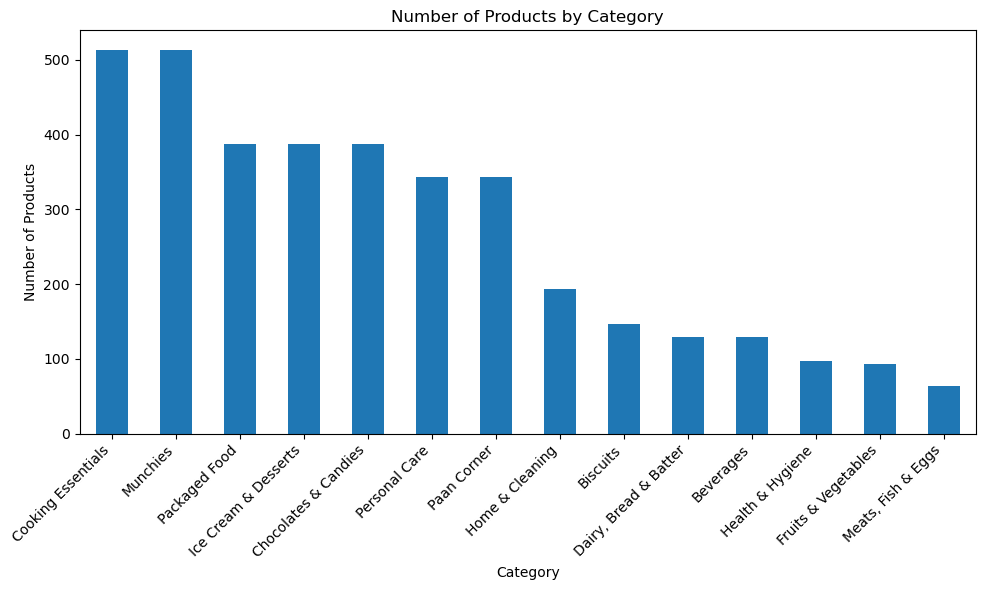

In [49]:
# Visualize product count by category
plt.figure(figsize=(10, 6))

category_product_count.plot(kind="bar")

plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [50]:
# Calculate average selling price for each category
avg_selling_price_by_category = (
    df_clean.groupby("Category")["selling_price_rupees"]
    .mean()
    .sort_values(ascending=False)
)

print("Average selling price by category:")
print(avg_selling_price_by_category)

Average selling price by category:
Category
Paan Corner              189.897959
Personal Care            189.897959
Meats, Fish & Eggs       164.095238
Health & Hygiene         145.855670
Home & Cleaning          141.448454
Chocolates & Candies     141.077320
Packaged Food            141.077320
Ice Cream & Desserts     141.077320
Cooking Essentials       140.826848
Munchies                 140.826848
Beverages                103.728682
Dairy, Bread & Batter    103.728682
Biscuits                  52.779592
Fruits & Vegetables       39.838710
Name: selling_price_rupees, dtype: float64


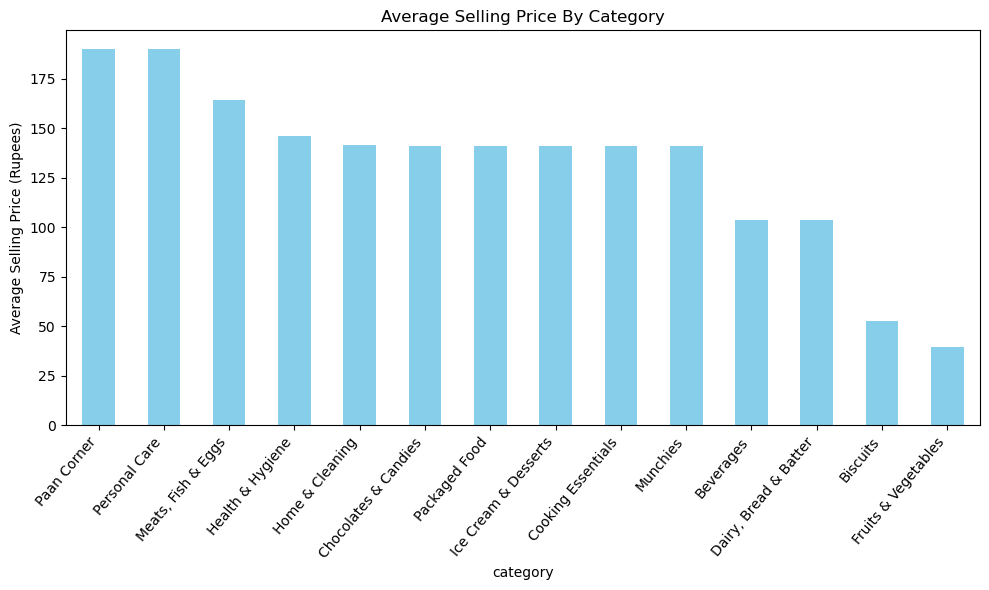

In [51]:
plt.figure (figsize = (10,6))
avg_selling_price_by_category.plot(kind = "bar", color = "skyblue")

plt.title("Average Selling Price By Category")
plt.xlabel("category")
plt.ylabel("Average Selling Price (Rupees)")
plt.xticks(rotation=50, ha = "right")
plt.tight_layout()
plt.show()

In [55]:
# Calculate average discount for each category
avg_discount_by_category =(
    df_clean.groupby("Category")["discountPercent"]
    .mean()
    .sort_values(ascending=False)
)

print("Average discount percentage by category:")
print(avg_discount_by_category)

Average discount percentage by category:
Category
Fruits & Vegetables      15.462366
Meats, Fish & Eggs       11.031746
Ice Cream & Desserts      8.324742
Packaged Food             8.324742
Chocolates & Candies      8.324742
Biscuits                  8.244898
Health & Hygiene          8.051546
Munchies                  7.163424
Cooking Essentials        7.163424
Beverages                 7.155039
Dairy, Bread & Batter     7.155039
Paan Corner               6.239067
Personal Care             6.239067
Home & Cleaning           5.675258
Name: discountPercent, dtype: float64


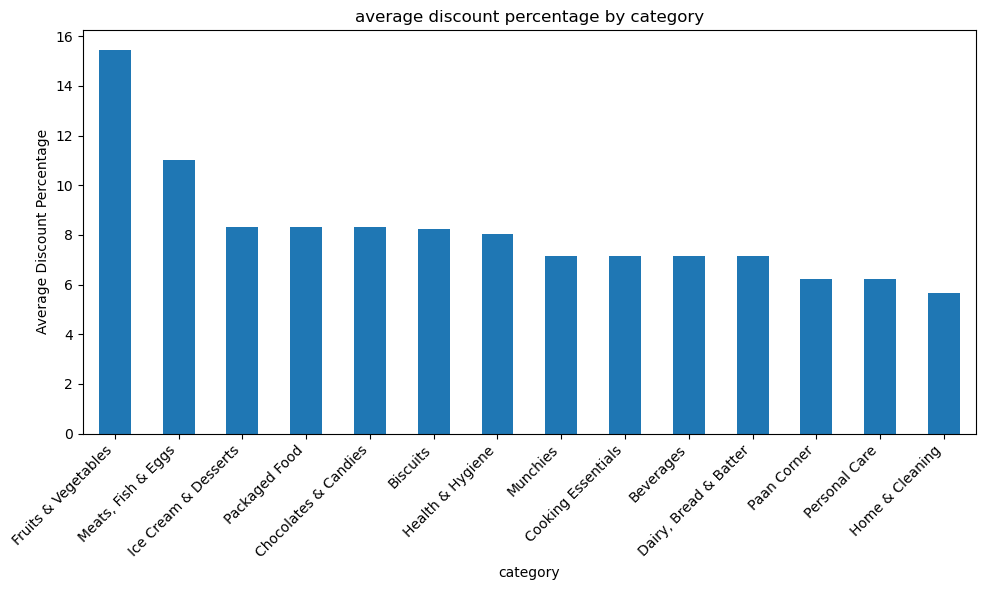

In [57]:
plt.figure(figsize=(10,6))
avg_discount_by_category.plot(kind="bar")

plt.title("average discount percentage by category")
plt.xlabel("category")
plt.ylabel("Average Discount Percentage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [58]:
# Count out-of-stock products by category
out_of_stock_by_category = (
    df_clean[df_clean["outOfStock"] == True]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

print("Out-of-stock products by category:")
print(out_of_stock_by_category)

Out-of-stock products by category:
Category
Cooking Essentials       64
Munchies                 64
Ice Cream & Desserts     45
Packaged Food            45
Chocolates & Candies     45
Biscuits                 42
Beverages                28
Dairy, Bread & Batter    28
Personal Care            21
Paan Corner              21
Home & Cleaning          19
Health & Hygiene         13
Meats, Fish & Eggs       12
Fruits & Vegetables       6
dtype: int64


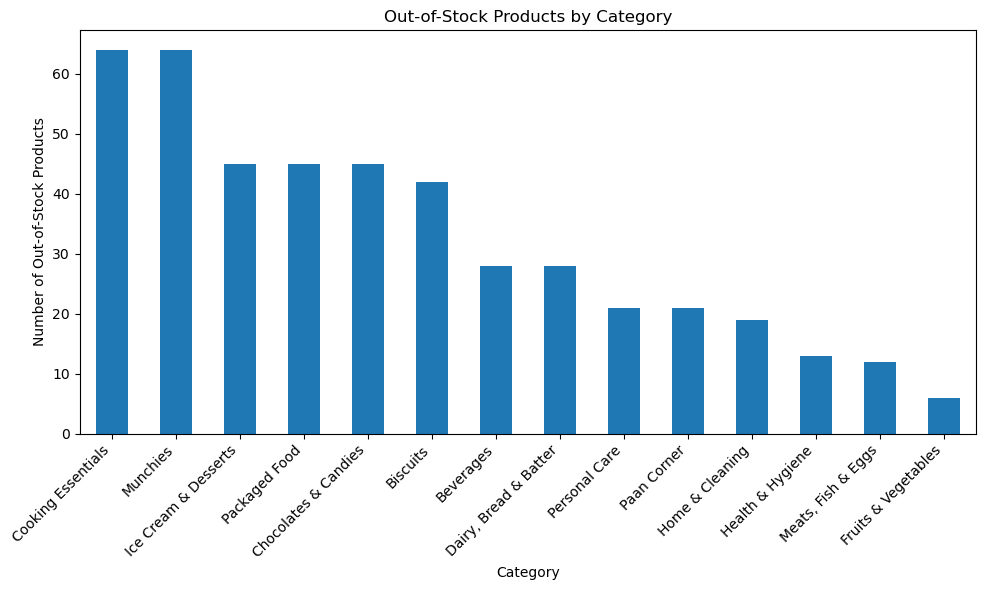

In [59]:
plt.figure(figsize=(10, 6))

out_of_stock_by_category.plot(kind="bar")

plt.title("Out-of-Stock Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Out-of-Stock Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 7.2 Product Analysis

Product-level analysis is performed to identify products with high savings, high prices, and other important product-level patterns.

In [60]:
# Find the products with the highest savings
top_savings_products = (
    df_clean[
        ["name", "Category", "mrp_rupees", "selling_price_rupees", "savings"]
    ]
    .sort_values("savings", ascending=False)
    .head(10)
)

print("Top 10 products with the highest savings:")
print(top_savings_products)

Top 10 products with the highest savings:
                                                   name              Category  \
517                Borges Extra Light Olive Oil Bottle     Cooking Essentials   
1031               Borges Extra Light Olive Oil Bottle               Munchies   
3016                              Pampers Pants - Large         Personal Care   
3360                              Pampers Pants - Large           Paan Corner   
1547                    Kelloggs Chocos - Moons & Stars         Packaged Food   
2323                    Kelloggs Chocos - Moons & Stars  Chocolates & Candies   
1935                    Kelloggs Chocos - Moons & Stars  Ice Cream & Desserts   
3367  Pampers Active Baby Diapers New Born Extra Small            Paan Corner   
3023  Pampers Active Baby Diapers New Born Extra Small          Personal Care   
254               Popular Essentials Californian Almond    Cooking Essentials   

      mrp_rupees  selling_price_rupees  savings  
517       2600.0

<Figure size 1000x600 with 0 Axes>

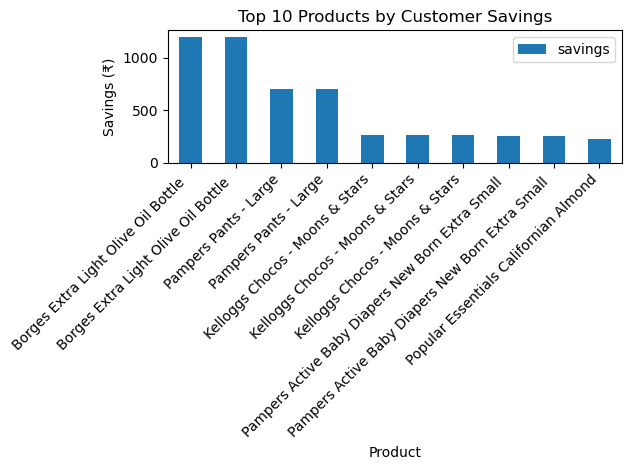

In [61]:
plt.figure(figsize=(10, 6))

top_savings_products.plot(
    x="name",
    y="savings",
    kind="bar"
)

plt.title("Top 10 Products by Customer Savings")
plt.xlabel("Product")
plt.ylabel("Savings (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [62]:
# Find the 10 most expensive products
most_expensive_products = (
    df_clean[
        ["name", "Category", "mrp_rupees", "selling_price_rupees"]
    ]
    .sort_values("selling_price_rupees", ascending=False)
    .head(10)
)

print("Top 10 most expensive products:")
print(most_expensive_products)


Top 10 most expensive products:
                                         name            Category  mrp_rupees  \
517      Borges Extra Light Olive Oil Bottle   Cooking Essentials      2600.0   
1031     Borges Extra Light Olive Oil Bottle             Munchies      2600.0   
363   Praakritik Natural Desi Gir Cow A2 Ghee  Cooking Essentials      1450.0   
877   Praakritik Natural Desi Gir Cow A2 Ghee            Munchies      1450.0   
144                        Saffola Gold (Jar)  Cooking Essentials      1240.0   
658                        Saffola Gold (Jar)            Munchies      1240.0   
635         Dhara Kachi Ghani Mustard Oil Jar            Munchies      1250.0   
121         Dhara Kachi Ghani Mustard Oil Jar  Cooking Essentials      1250.0   
1025       Dhara Filtered Groundnut Oil (Jar)            Munchies      1050.0   
511        Dhara Filtered Groundnut Oil (Jar)  Cooking Essentials      1050.0   

      selling_price_rupees  
517                 1399.0  
1031              

<Figure size 1000x600 with 0 Axes>

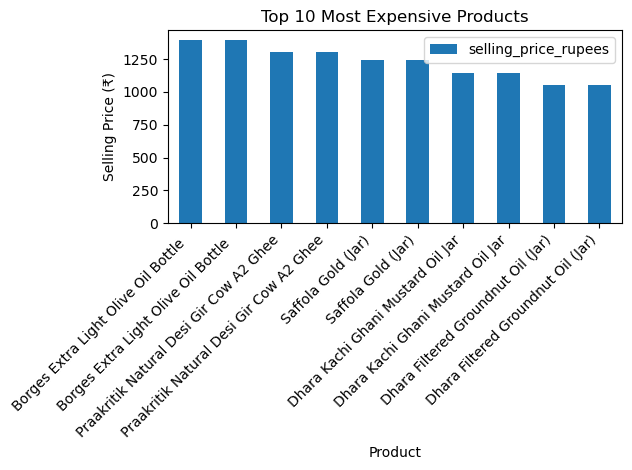

In [63]:
plt.figure(figsize=(10, 6))

most_expensive_products.plot(
    x="name",
    y="selling_price_rupees",
    kind="bar"
)

plt.title("Top 10 Most Expensive Products")
plt.xlabel("Product")
plt.ylabel("Selling Price (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Find the 10 products with the highest discount percentage
top_discount_products = (
    df_clean[
        ["name", "Category", "mrp_rupees", "selling_price_rupees", "discountPercent"]
    ]
    .sort_values("discountPercent", ascending=False)
    .head(10)
)

print("Top 10 products with the highest discount:")
print(top_discount_products)

In [66]:
plt.figure(figsize=(10, 6))

top_discount_products.plot(
    x="name",
    y="discountPercent",
    kind="bar",
    legend=False,
    color="teal"
)

plt.title("Top 10 Products by Discount Percentage")
plt.xlabel("Product")
plt.ylabel("Discount (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

NameError: name 'top_discount_products' is not defined

<Figure size 1000x600 with 0 Axes>